## Supplemental figure 2:$U_c/U_0$ against other things

In [ ]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# from scipy.stats import linregress
# import matplotlib.patches as patches
from matplotlib.lines import Line2D

# Use given style and color maps
from colors import type_marker_map

plt.style.use("james2026lock.mplstyle")

# constants
rho_water = 998.2  # Freshwater density [kg/m³]
rho_bent = 2277  # Wetted bentonite density [kg/m³]
h0 = 0.25  # initial water height [m]
l0 = 0.27  # mixing chamber length [m]
v0 = h0 * l0
a_thresh = 0.06  # m/s² for example (below this velocity taken as roughly constant)

# load experiment table
metadata = pd.read_csv("data/metadata.csv")
folder = "/Users/cara/Library/CloudStorage/OneDrive-UBC/PhD/Experiments/2025/Experiment_files/datafiles"

In [6]:
metadata.head()

,exp_code,file_name,type,cont,mixing,C0,rho,del_rho,g_prime,u_0,hose diameter,Q,amp,freq,U_mix,Ri_0,u_c
0,NM1s,SN0,saline,none,none,0.0,999.93,1.73,0.017,0.065,NaN,NaN,NaN,NaN,NaN,NaN,0.030452
1,NM2s,SN5,saline,none,none,0.0,1000.27,2.07,0.020,0.071,NaN,NaN,NaN,NaN,NaN,NaN,0.036205
2,NM3s,Saline_025gL,saline,none,none,0.0,1001.46,3.26,0.032,0.089,NaN,NaN,NaN,NaN,NaN,NaN,0.050752
3,NM4s,Saline_5gL,saline,none,none,0.0,1004.62,6.42,0.063,0.126,NaN,NaN,NaN,NaN,NaN,NaN,0.061334
4,NM5s,Saline_10gL,saline,none,none,0.0,1010.97,12.77,0.125,0.177,NaN,NaN,NaN,NaN,NaN,NaN,0.081292


<>:21: SyntaxWarning: invalid escape sequence '\,'
<>:21: SyntaxWarning: invalid escape sequence '\,'
/var/folders/v4/_48l42jj6nnf6xdxm2f8xp7c0000gp/T/ipykernel_85495/3177384274.py:21: SyntaxWarning: invalid escape sequence '\,'
  xlabel="$\\Delta \\rho$ (kg$\,$m$^{-3}$)",


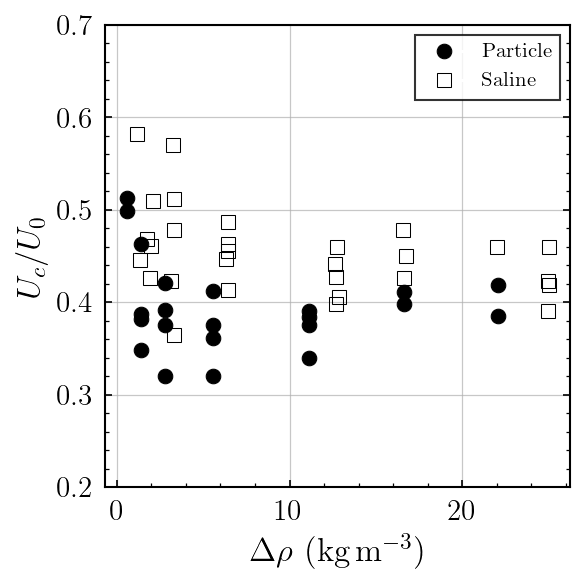

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))

for t, marker in type_marker_map.items():
    df_sub = metadata[metadata["type"] == t]
    c = "none" if t == "saline" else "black"
    ax.plot(
        df_sub["del_rho"],
        df_sub["u_c"] / df_sub["u_0"],
        color=c,
        marker=marker,
        markerfacecolor=c,
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
        linestyle="",
    )

ax.set(
    # xlim=[0,5],
    ylim=[0.2, 0.7],
    xlabel="$\\Delta \\rho$ (kg$\,$m$^{-3}$)",
    ylabel="$U_c/U_0$",
)


ri_legend = []

ri_legend.extend(
    [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Particle",
            markerfacecolor="black",
            markeredgecolor="k",
            markeredgewidth=0.5,
            markersize=7,
        ),
        Line2D(
            [0],
            [0],
            marker="s",
            color="w",
            label="Saline",
            markerfacecolor="white",
            markeredgecolor="k",
            markeredgewidth=0.5,
            markersize=7,
        ),
    ]
)

ax.legend(
    handles=ri_legend,
    loc="upper right",
    bbox_to_anchor=(1, 1),
    fontsize=10,
)

plt.savefig("figures/figure_11_ri.png", bbox_inches="tight", dpi=300)
plt.show()